In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import f1_score

In [198]:
RANDOM_SEED = 65

Text(0, 0.5, 'X2')

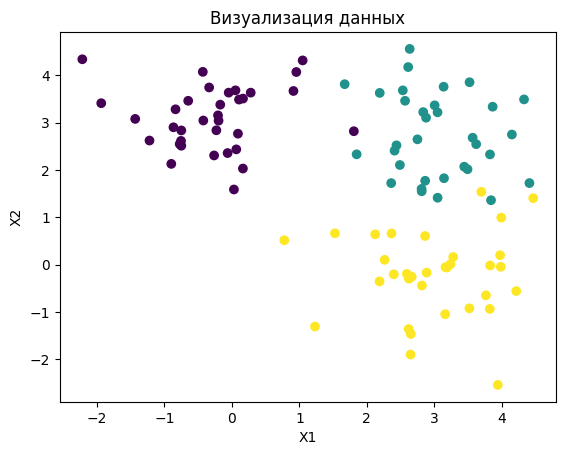

In [199]:
X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)], 
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

In [200]:
depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, 
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,65
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


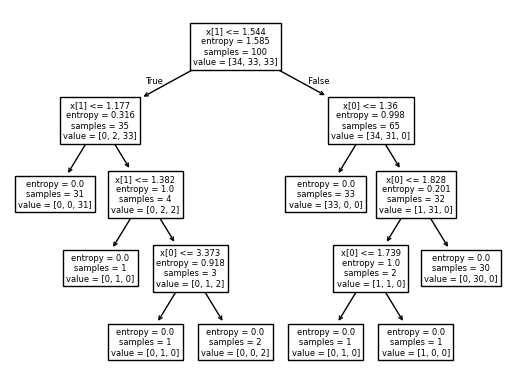

In [201]:
tree.plot_tree(clf_tree) 
plt.show()

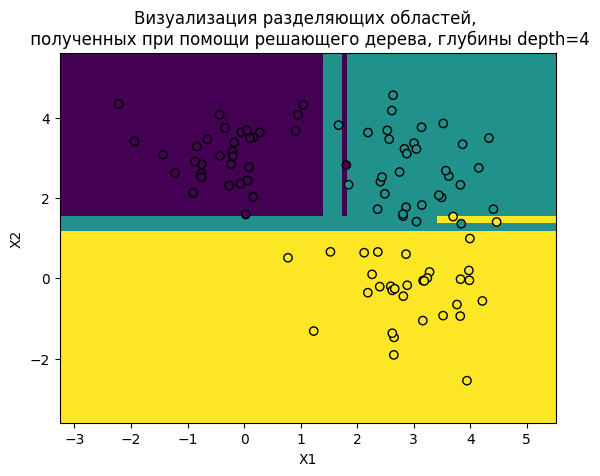

In [202]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [203]:
y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 0 33  0]
 [ 0  0 33]]
Accuracy = 1.0
F1_score = 1.0


In [204]:
observation_new = [[2, 1]]

In [205]:
clf_tree.predict(observation_new)

array([2])

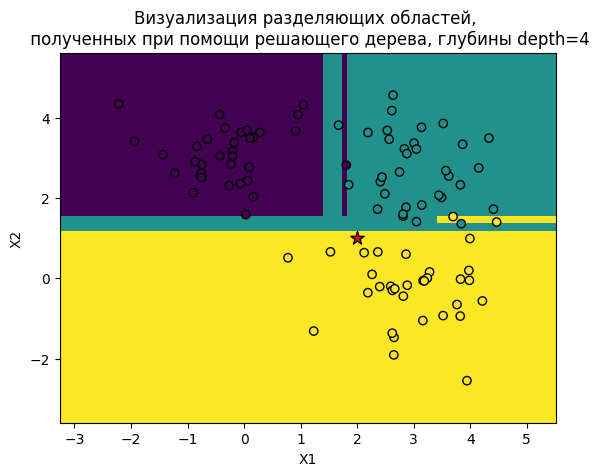

In [212]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.scatter(observation_new[0][0], observation_new[0][1], color='red', s=100, 
           marker='*', edgecolors='black', linewidth=1, label='Новое наблюдение')

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [213]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

In [219]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree

In [220]:
X = X.reshape(-1, 1)
depth=3
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
reg_tree.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,65
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


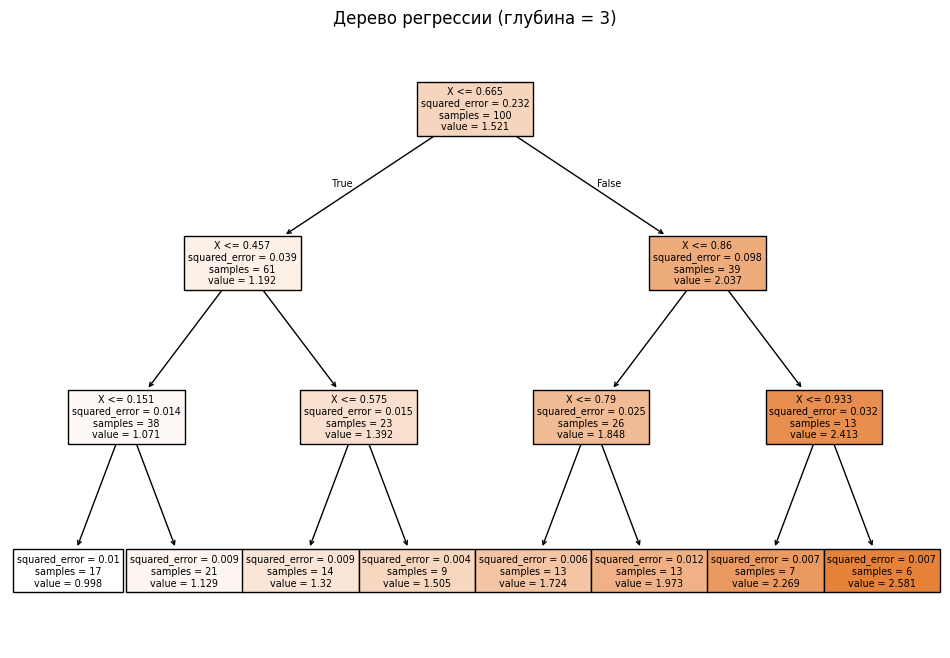

In [221]:
plt.figure(figsize=(12, 8))
plot_tree(reg_tree, filled=True, feature_names=['X'])
plt.title(f'Дерево регрессии (глубина = {depth})')
plt.show()

In [223]:
y_pred_reg = reg_tree.predict(X)

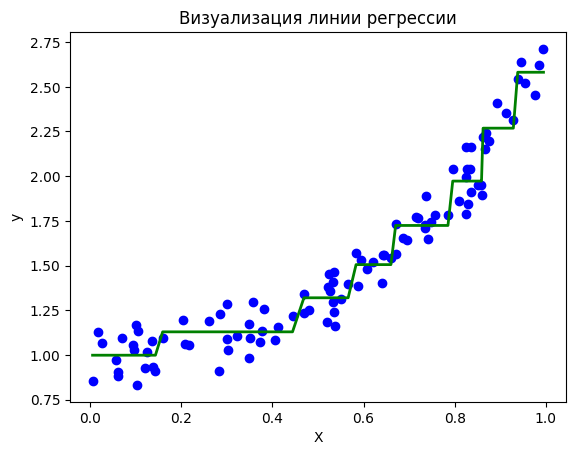

In [224]:
plt.scatter(X, y, c="b")

plt.plot(X, y_pred_reg, "g", lw=2)

plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y');

In [228]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [229]:
print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.9626080190979239
MSE=  0.008656972941076856


In [230]:
observation_new = [[0.7]]

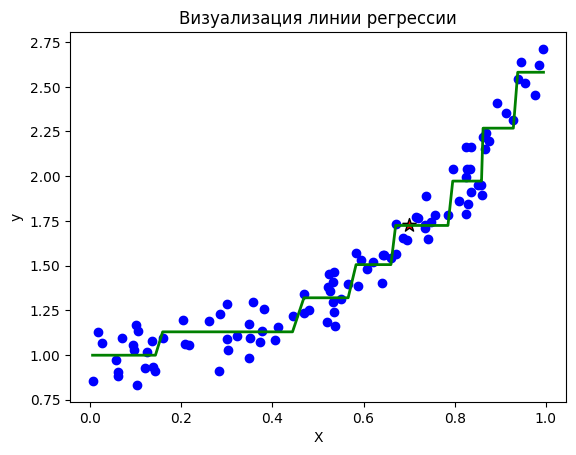

In [235]:
plt.scatter(X, y, c="b")
plt.plot(X, y_pred_reg, "g", lw=2)
plt.scatter(observation_new[0][0], reg_tree.predict(observation_new)[0], color='red', s=100, marker='*', edgecolors='black')
plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

## Практическая работа

### 1. Загрузка данных и изображение на графике

In [238]:
from sklearn.datasets import load_iris

In [239]:
iris = load_iris()
X = iris.data[:, 2:]
y = iris.target

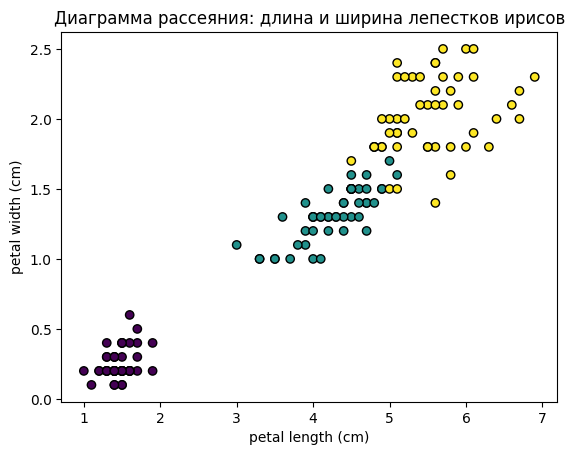

In [246]:
scatter = plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='black')
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])
plt.title('Диаграмма рассеяния: длина и ширина лепестков ирисов')
plt.show()

### 2. Модель классификационного дерева

In [247]:
iris = load_iris()
X = iris.data[:, 2:]
y = iris.target

In [248]:
depth = 4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
clf_tree.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


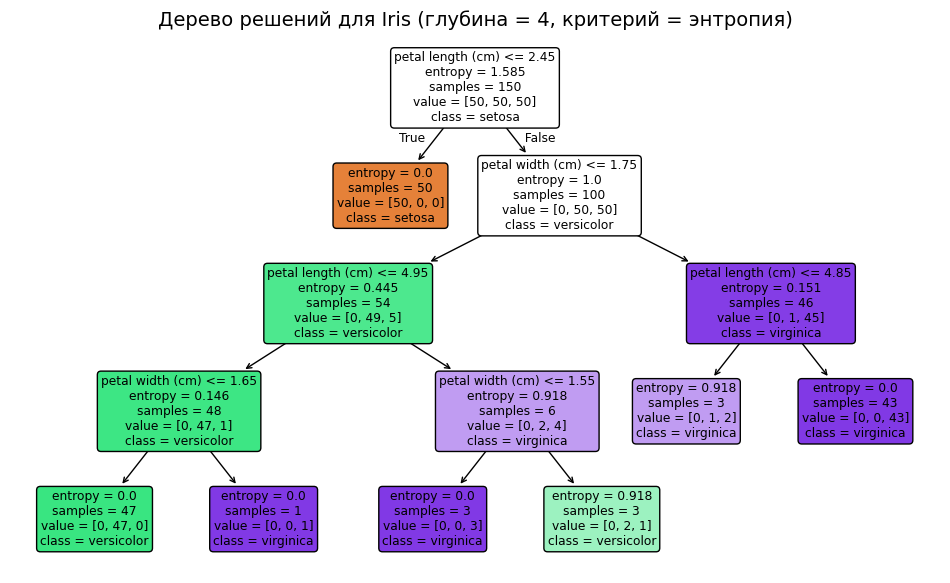

In [255]:
plt.figure(figsize=(12, 7))
plot_tree(clf_tree, 
          filled=True, 
          feature_names=iris.feature_names[2:],
          class_names=iris.target_names,
          rounded=True)
plt.title(f'Дерево решений для Iris (глубина = {depth}, критерий = энтропия)', fontsize=14)
plt.show()

### 3. Модель классификационного дерева с разными глубинами

In [266]:
xx, yy = np.meshgrid(np.arange(X[:, 0].min()-0.5, X[:, 0].max()+0.5, 0.02),
                     np.arange(X[:, 1].min()-0.5, X[:, 1].max()+0.5, 0.02))

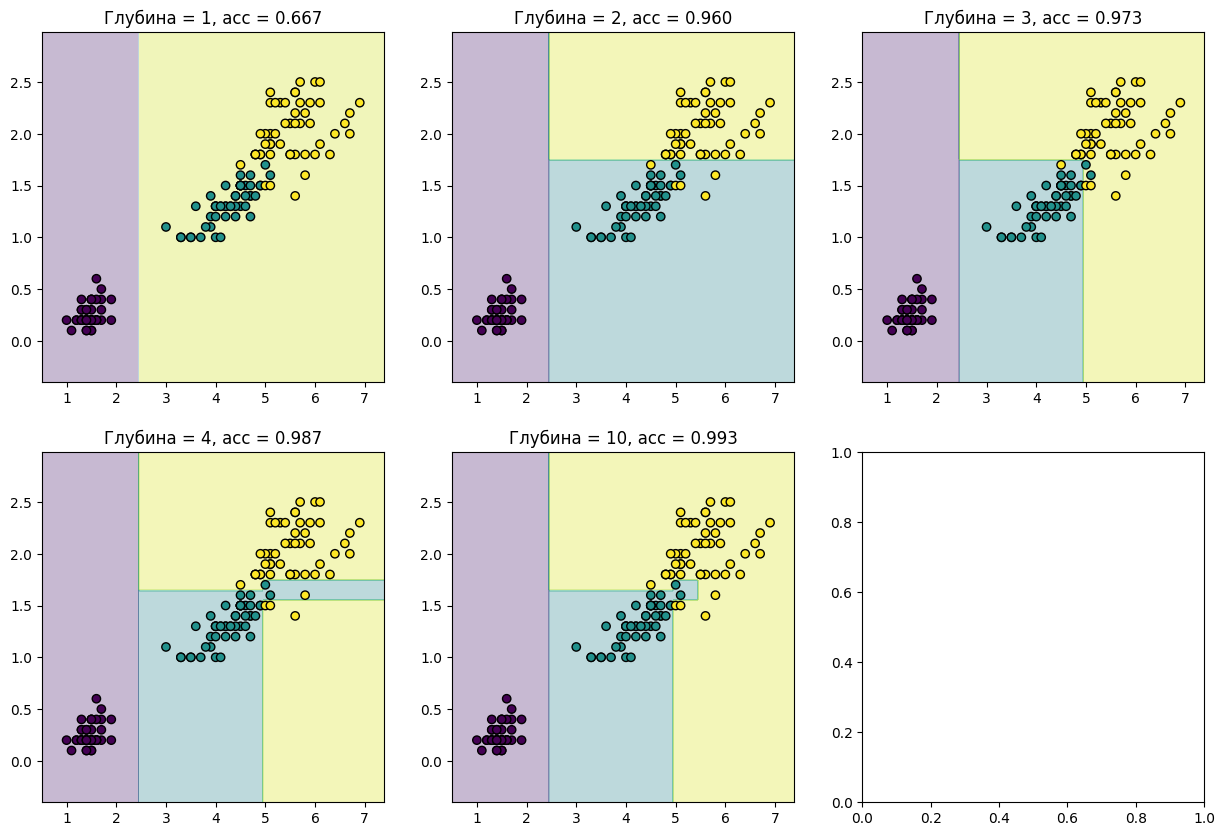

In [276]:
depths = [1, 2, 3, 4, 10]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, depth in enumerate(depths):
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X, y)
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    axes[idx//3, idx%3].contourf(xx, yy, Z, alpha=0.3)
    axes[idx//3, idx%3].scatter(X[:, 0], X[:, 1], c=y, edgecolors='black')
    axes[idx//3, idx%3].set_title(f'Глубина = {depth}, acc = {clf.score(X, y):.3f}')

### 4. Метрики для оценки работы моделей

In [280]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [286]:
results = []

In [287]:
depths = [2, 3, 4, 10]

In [294]:
for depth in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
    clf.fit(X, y)
    y_pred = clf.predict(X)
    
    results.append({
        'Глубина': depth,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision (macro)': precision_score(y, y_pred, average='macro'),
        'Recall (macro)': recall_score(y, y_pred, average='macro'),
        'F1-score (macro)': f1_score(y, y_pred, average='macro')
    })

df = pd.DataFrame(results)
df

,Глубина,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
0,2,0.960000,0.961889,0.960000,0.959936
1,3,0.973333,0.973825,0.973333,0.973323
2,4,0.993333,0.993464,0.993333,0.993333
3,10,1.000000,1.000000,1.000000,1.000000


**Лучшая модель:** глубина 3-4 (97-98% точности)

- Глубина 2: 96% — уже хорошо
- Глубина 3-4: 97-98% — оптимальный баланс качества и простоты  
- Глубина 10: 99% — максимальная точность, но риск переобучения

### 5. Изучаем датасет ирисов

In [295]:
iris = load_iris()
X = iris.data
y = iris.target

In [296]:
depth = 4
clf = DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=42)
clf.fit(X, y)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [297]:
y_pred = clf.predict(X)

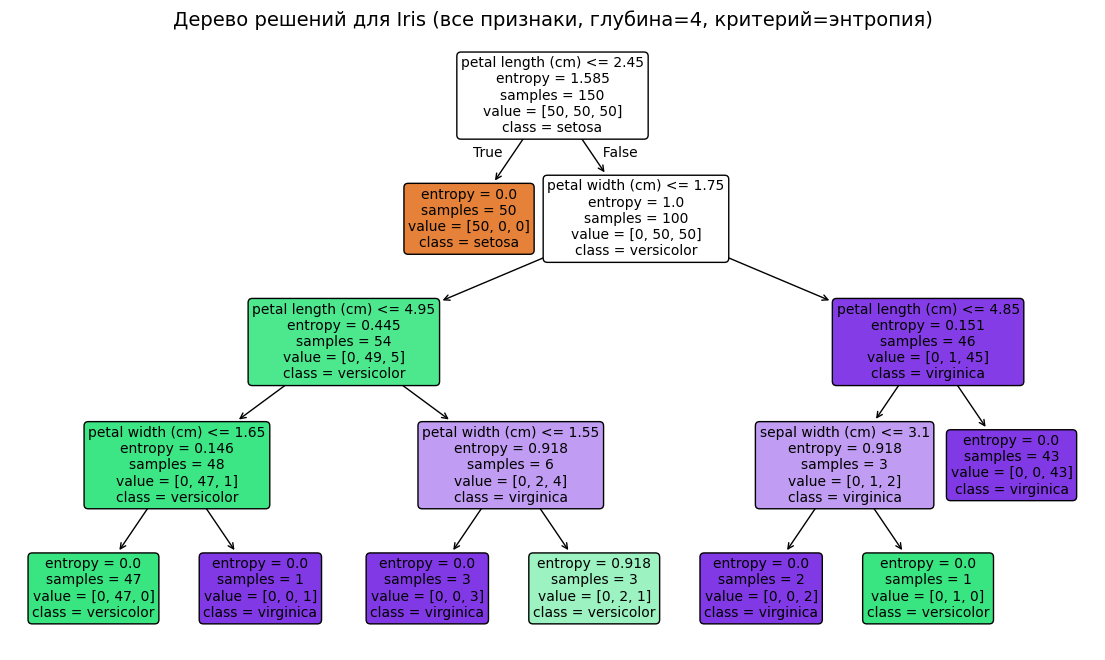

In [307]:
plt.figure(figsize=(14, 8))
plot_tree(clf, 
          filled=True, 
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          rounded=True,
          fontsize=10)
plt.title(f'Дерево решений для Iris (все признаки, глубина={depth}, критерий=энтропия)', fontsize=14)
plt.show()

In [308]:
clf.score(X, y)

0.9933333333333333

In [309]:
confusion_matrix(y, y_pred)

array([[50,  0,  0],
       [ 0, 50,  0],
       [ 0,  1, 49]])

### 6. Визуализация признака на диаграмме

In [310]:
from sklearn.datasets import fetch_california_housing

In [311]:
housing = fetch_california_housing()
X = housing.data[:, 3].reshape(-1, 1)
y = housing.target

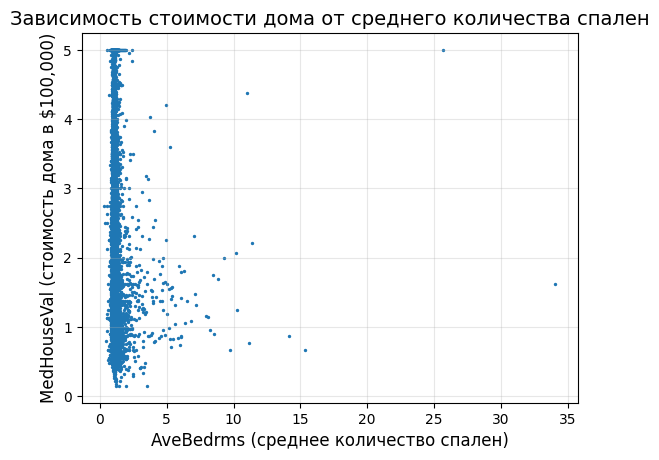

In [321]:
plt.scatter(X, y, s=2)
plt.xlabel('AveBedrms (среднее количество спален)', fontsize=12)
plt.ylabel('MedHouseVal (стоимость дома в $100,000)', fontsize=12)
plt.title('Зависимость стоимости дома от среднего количества спален', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### 7. Модель регрессионного дерева с фиксированным random_state

In [349]:
housing = fetch_california_housing()
X = housing.data[:, 3].reshape(-1, 1)
y = housing.target

In [350]:
reg_tree = DecisionTreeRegressor(random_state=0)
reg_tree.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [351]:
y_pred = reg_tree.predict(X)

In [352]:
reg_tree.score(X, y)

0.679172913720798

In [353]:
reg_tree.get_depth()

80

### 8. Граф дерева решений и получившаяся кусочная линия регрессии

In [356]:
y_pred = reg_tree.predict(X)

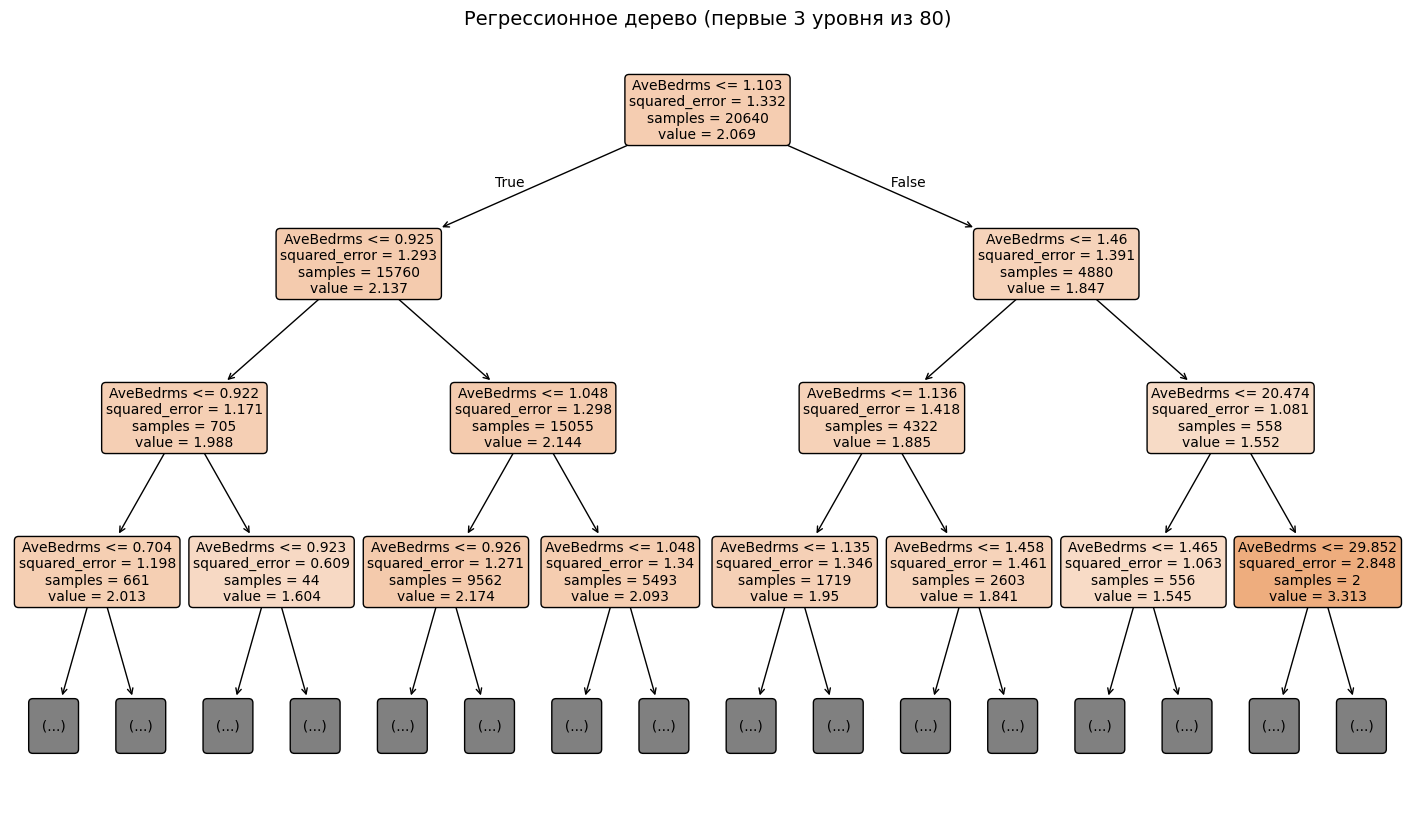

In [368]:
plt.figure(figsize=(18, 10))
plot_tree(reg_tree, 
          max_depth=3,
          filled=True, 
          feature_names=['AveBedrms'],
          rounded=True,
          fontsize=10)
plt.title('Регрессионное дерево (первые 3 уровня из 80)', fontsize=14)
plt.show()

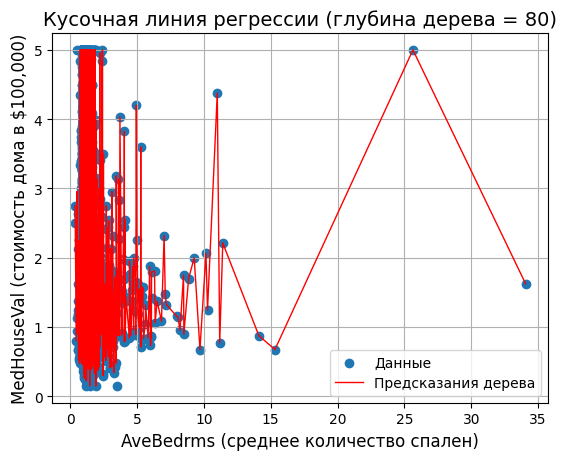

In [379]:
X_sorted = np.sort(X, axis=0)
y_pred_sorted = reg_tree.predict(X_sorted)
plt.scatter(X, y, label='Данные')
plt.plot(X_sorted, y_pred_sorted, 'r-', linewidth=1, label='Предсказания дерева')

plt.xlabel('AveBedrms (среднее количество спален)', fontsize=12)
plt.ylabel('MedHouseVal (стоимость дома в $100,000)', fontsize=12)
plt.title(f'Кусочная линия регрессии (глубина дерева = {reg_tree.get_depth()})', fontsize=14)
plt.legend()
plt.grid()
plt.show()

### 9. Качество работы модели на новом наблюдении

In [380]:
housing = fetch_california_housing()
X = housing.data[:, 3].reshape(-1, 1)
y = housing.target

In [381]:
reg_tree = DecisionTreeRegressor(random_state=0)
reg_tree.fit(X, y)

y_pred = reg_tree.predict(X)

In [382]:
observation_new = np.array([[2.5]])
prediction = reg_tree.predict(observation_new)

In [383]:
print(f"Новое наблюдение (AveBedrms = {observation_new[0][0]}):")
print(f"Предсказанная стоимость дома: ${prediction[0] * 100000:.2f}")

Новое наблюдение (AveBedrms = 2.5):
Предсказанная стоимость дома: $162500.00


In [384]:
observations = np.array([[1.0], [2.0], [3.0], [4.0], [5.0]])
predictions = reg_tree.predict(observations)

for obs, pred in zip(observations, predictions):
    print(f"AveBedrms = {obs[0]:.1f} -> стоимость: ${pred * 100000:.2f}")

AveBedrms = 1.0 -> стоимость: $218991.39
AveBedrms = 2.0 -> стоимость: $148650.00
AveBedrms = 3.0 -> стоимость: $41300.00
AveBedrms = 4.0 -> стоимость: $244000.00
AveBedrms = 5.0 -> стоимость: $225000.00


### 10. Загрузка всего датасета fetch_california_housing

In [386]:
from sklearn.datasets import fetch_california_housing

In [387]:
housing = fetch_california_housing()
X = housing.data
y = housing.target

In [388]:
reg_tree = DecisionTreeRegressor(random_state=0)
reg_tree.fit(X, y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [389]:
y_pred = reg_tree.predict(X)

In [390]:
reg_tree.score(X, y)

1.0

In [391]:
reg_tree.get_depth()

40

In [392]:
reg_tree.get_n_leaves()

np.int64(19803)

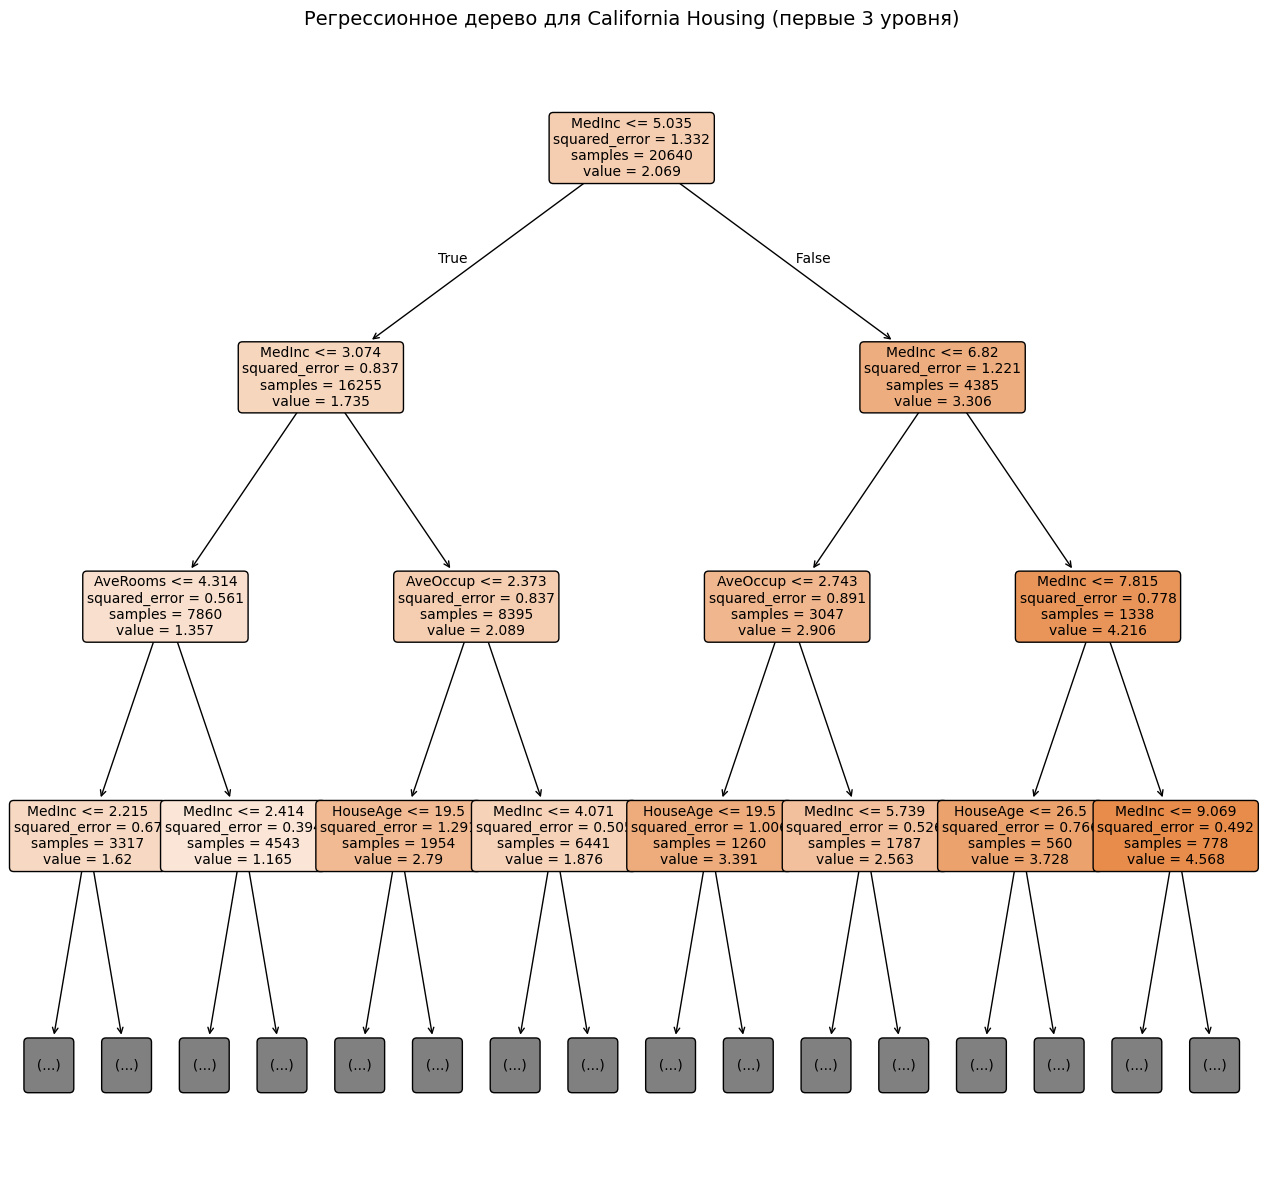

In [399]:
plt.figure(figsize=(13, 12))
plot_tree(reg_tree, 
          max_depth=3,
          filled=True, 
          feature_names=housing.feature_names,
          rounded=True,
          fontsize=10)
plt.title('Регрессионное дерево для California Housing (первые 3 уровня)', fontsize=14)
plt.tight_layout()
plt.show()